# Phytoplankton Phenology Study in the Northwest Atlantic Ocean

#### Import Python Libraries

In [2]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy
import pandas as pd
from shapely.ops import unary_union
import cartopy.feature as cfeature
import geopandas as gpd
from shapely.geometry import mapping
from shapely.geometry import Polygon
import rioxarray
import sys
sys.path.append(r'C:\Users\grace.davis\Documents\GitHub\RESOURCES\python')
import utilities
from utilities import get_prod_files
import cmocean
from matplotlib.colors import LogNorm
import cartopy.crs as crs


## Part 1: Bloom Detection Method Testing

### Threshold Method

#### Set the threshold percentage variable

In [ ]:
#Enter a threshold percentage as a decimal, the default is 0.05
thld = 0.05

#### Function for determining the climatological threshold value
Based on the climatological median, this function finds a certain percentage of that median and adds it to the median to get a threshold value for determining phytoplankton blooms
* Must include:
    * Threshold percentage = thld (thld=0.05 by default)
    * Path to climatology files = path (set to NES Annual Climatology 1997 - 2020 by default)

In [ ]:
#Define a function to return the threshold value based on the regional climatology.
def threshold_value(thld = 0.05, path = None):
    if path == None:
        file = get_prod_files('CHL',mapping='NES',period='ANNUAL',verbose=True) #finds path for the annual climatology file
        base_ds = xr.open_dataset(file[0]) #opens netCDF file
    else:
        base_ds = xr.open_dataset(path)
    median_CHL = base_ds.CHL_median #grabs CHL_median variable
    thld_value = median_CHL*(1+thld) #Sets threshold value per latitude and longitude point
    return(thld_value)

clim_med = threshold_value()
#print(clim_med)

#### Plotting the Climatological Threshold

In [ ]:
clim_med = clim_med.squeeze()
bathym = cfeature.NaturalEarthFeature(name='bathymetry_K_200', scale='10m', category='physical')
bathym=unary_union(list(bathym.geometries()))
fig = plt.figure(figsize=(15,8))
map_projection = cartopy.crs.PlateCarree()
ax = plt.axes(projection=map_projection)
im = plt.pcolormesh(clim_med.lon,
                    clim_med.lat,
                    clim_med,
                    cmap=cmocean.cm.algae,
                    norm=LogNorm(vmin=0.1, vmax=10.0)
)
custom_ticks = [0.1,1,10]
cb = plt.colorbar(im,shrink=0.8,label='Chlorophyll a Threshold ($mg/m^3$)',ticks=custom_ticks,format='%g') #$ $ makes it a LaTEX function so it actually formats as an equation

ax.add_feature(cartopy.feature.COASTLINE, linewidth=1)
ax.add_feature(cartopy.feature.LAND, zorder=100, facecolor='lightgrey')
ax.add_geometries(bathym, facecolor='none', edgecolor='black', crs=cartopy.crs.PlateCarree()) #Adding the shelf break line
ax.set_extent([-77,-62,37,47])
ax.set_xlabel('Longitude ($^o$)', fontsize=12)
ax.set_ylabel('Latitude ($^o$)', fontsize=12)
ax.gridlines(draw_labels=True)
ax.set_title('Chlorophyll a Climatological Median Threshold', fontsize=24)

#### Create a mask to filter data for bloom conditions

This function (bloom_mask_Boolean) takes the input data and determines if values exceed the climatological threshold determined above (or found via the threshold_value function). If the value is less than or equal to the threshold, then it is reported as false. If it is greater than the threshold, it is reported as true. You must run the threshold function prior to running this function as it requires its value to be saved as clim_med.
* Must include
    * Path to files = path (set to D8 NES shelf files by default)

In [ ]:
clim_med = threshold_value()
def bloom_mask_Boolean(path=None): #Produces True and False values
    if path == None:
        files = get_prod_files('CHL',mapping='NES',period='D8') #Finds all 8 day rolling mean files for NWA
        ds = xr.open_mfdataset(files)
    else:
        ds = xr.open_mfdataset(path)
    med_CHL = ds.CHL_median #Extracts CHL_mean variable for the files
    clim_med_new = clim_med.squeeze('time', drop=True) #Removes time dimension from climatological mean
    is_bloom_CHL = med_CHL > clim_med #Is the median chl-a in each files greater than the climatological mean? Creates a Boolean array of trues and falses.
    return is_bloom_CHL

This function (bloom_mask_numeric) functions similar to bloom_mask_Boolean, except it reports false values as 0 and true values retain their actual value. You must run the threshold function prior to running this function as it requires its value to be saved as clim_med.
* Must include:
    * Path to files = path (set to D8 NES shelf files by default)

In [ ]:
def bloom_mask_numeric(path=None): #Produces 0 and actual values
    if path == None:
        files = get_prod_files('CHL',mapping='NES',period='D8') #Finds all 8 day rolling mean files for NWA
        ds = xr.open_mfdataset(files)
    else:
        ds = xr.open_mfdataset(path)
    med_CHL = ds.CHL_median #Extracts CHL_mean variable for the files
    clim_med_new = clim_med.squeeze('time', drop=True) #Removes time dimension from climatological mean, FIX THIS LINE
    is_bloom_CHL = med_CHL.where(med_CHL > clim_med_new, 0) #Turns false into 0 and trues retain their value
    return is_bloom_CHL

bloom = bloom_mask_numeric()

#### Mask Intervals
Finding the climatological threshold at a few different inteverals (5%, 10%, 15%, 20%, 25%, and 30%)

In [ ]:
thld_value = [0.05,0.1,0.15,0.2,0.25,0.3]
clim_med = threshold_value()
bloom_5 = bloom_mask_numeric()
clim_med = threshold_value(thld=thld_value[1])
bloom_10 = bloom_mask_numeric()
clim_med = threshold_value(thld=thld_value[2])
bloom_15 = bloom_mask_numeric()
clim_med = threshold_value(thld=thld_value[3])
bloom_20 = bloom_mask_numeric()
clim_med = threshold_value(thld=thld_value[4])
bloom_25 = bloom_mask_numeric()
clim_med = threshold_value(thld=thld_value[5])
bloom_30 = bloom_mask_numeric()

Plotting all of the masks (5% - 30%)
<br> Must pick a day of the year from (INPUT VALUE RANGE HERE)

In [ ]:
bathym = cfeature.NaturalEarthFeature(name='bathymetry_K_200', scale='10m', category='physical')
bathym=unary_union(list(bathym.geometries()))
map_projection = cartopy.crs.PlateCarree()

DOY = 7181
datasets = [
    (bloom_5[DOY],"Chlorophyll a 5% Mask"),
    (bloom_10[DOY], "Chlorophyll a 10% Mask"),
    (bloom_15[DOY], "Chlorophyll a 15% Mask"),
    (bloom_20[DOY], "Chlorphyll a 20% Mask"),
    (bloom_25[DOY], "Chlorophyll a 25% Mask"),
    (bloom_30[DOY], "Chlorophyll a 30% Mask"),
    ]

fig, axes = plt.subplots(3,2,figsize=(18,16),subplot_kw={"projection":map_projection})
axes_flat = axes.flatten()

im= None

for i, (data,title) in enumerate(datasets):
    ax = axes_flat[i]
    im = ax.pcolormesh(data.lon,
                data.lat,
                data,
                cmap=cmocean.cm.algae,
                norm=LogNorm(vmin=0.1, vmax=10.0)
    )
    ax.add_feature(cartopy.feature.COASTLINE, linewidth=1)
    ax.add_feature(cartopy.feature.LAND, zorder=100, facecolor='lightgrey')
    ax.add_geometries(bathym, facecolor='none', edgecolor='black', crs=cartopy.crs.PlateCarree()) #Adding the shelf break line
    ax.set_xlabel('Longitude ($^o$)', fontsize=12)
    ax.set_ylabel('Latitude ($^o$)', fontsize=12)
    ax.set_extent([-77,-63,34.5,46])
    ax.set_title(title, fontsize=14) #Plot headings
    gl = ax.gridlines(draw_labels=True)
    gl.top_labels = False
    gl.right_labels = False

custom_ticks = [0.1,1,10]
cb = fig.colorbar(im,ax=axes,shrink=0.5,label='Chlorophyll a Concentration ($mg/m^3$)',ticks=custom_ticks,format='%g')
fig.suptitle("Chlorophyll a Masks Based on NES Annual Climatology",fontsize=20) #Overall figure heading

#### Histograms of Data

Create the functions to subset the data

In [ ]:
ds = xr.open_mfdataset(r'C:\Users\grace.davis\Documents\GitHub\DATASETS\OCCCI\V6.0\PRODUCTS\NES_4KM_DAY8\CHL\D8*.nc')

Function to clip the median chl-a data for a specific longitude and latitude
* Must input 
    * Minimum latitude: lat_min
    * Maximum latitude: lat_max
    * Minimum longitude: lon_min
    * Maximum longitude: lon_max

In [ ]:
def hist_local_chl(lat_min,lat_max,lon_min,lon_max,region_title=None):
    lat_min = lat_min
    lat_max = lat_max
    lon_min = lon_min
    lon_max = lon_max
    ds_local = ds.CHL_median.sel(
    lat=slice(lat_min,lat_max),
    lon=slice(lon_min,lon_max)
    )
    ds_local = ds_local.mean(dim=['lat','lon'])
    return ds_local

Function to clip the climatological data to the area 
* Must include
    * Path to file: path =
    * Minimum latitude: lat_min
    * Maximum latitude: lat_max
    * Minimum longitude: lon_min
    * Maximum longitude: lon_max


In [ ]:
def hist_clim_local(lat_min,lat_max,lon_min,lon_max,region_title=None,path=None):
    if path == None:
        clim = xr.open_dataset(r'C:\Users\grace.davis\Documents\GitHub\DATASETS\OCCCI\V6.0\PRODUCTS\NES_4KM_CLIMATOLOGY\CHL\ANNUAL_1998_2020-OCCCI-CHL-NES-STATS.nc')
    else:
        clim = xr.open_dataset(path)
    clim_med = clim.CHL_median
    lat_min = lat_min
    lat_max = lat_max
    lon_min = lon_min
    lon_max = lon_max
    clim_med = clim_med.sel(
    lat=slice(lat_min,lat_max),
    lon=slice(lon_min,lon_max)
    )
    clim_med_bounded = clim_med.mean(dim=['lat','lon'])
    return clim_med_bounded

Function builds a square (polygon) of the area to plot
* Must include
    * Minimum latitude: lat_min
    * Maximum latitude: lat_max
    * Minimum longitude: lon_min
    * Maximum longitude: lon_max

In [ ]:
def bound_local(lat_min,lat_max,lon_min,lon_max): #Builds polygon shape for the map
    coords = [(lon_min,lat_min),
              (lon_max,lat_min),
              (lon_max,lat_max),
              (lon_min,lat_max),
              (lon_min,lat_min)]
    box_polygon = Polygon(coords)
    return box_polygon

Assign variables to the various datasets for plotting

In [62]:
ds_GOM = hist_local_chl(lat_min=44,lat_max=43,lon_min=-69,lon_max=-68,region_title='Gulf of Maine')
ds_GB = hist_local_chl(lat_min=41.7,lat_max=40.7,lon_min=-68,lon_max=-67,region_title='Georges Bank')
ds_MAB = hist_local_chl(lat_min=39.5,lat_max=38.5,lon_min=-74,lon_max=-73,region_title='Middle Atlantic Bight')
clim_GOM = hist_clim_local(lat_min=44,lat_max=43,lon_min=-69,lon_max=-68,region_title='Gulf of Maine')
clim_GB = hist_clim_local(lat_min=41.7,lat_max=40.7,lon_min=-68,lon_max=-67,region_title='Georges Bank')
clim_MAB = hist_clim_local(lat_min=39.5,lat_max=38.5,lon_min=-74,lon_max=-73,region_title='Middle Atlantic Bight')
location_GOM = bound_local(lat_min=44,lat_max=43,lon_min=-69,lon_max=-68)
location_GB = bound_local(lat_min=41.7,lat_max=40.7,lon_min=-68,lon_max=-67)
location_MAB = bound_local(lat_min=39.5,lat_max=38.5,lon_min=-74,lon_max=-73)

[1.2069457]
[1.5819888]
[0.90563434]


📊 Matched CLIMATOLOGY map → NES_4KM_CLIMATOLOGY
📂 Transformed path to CLIMATOLOGY: C:\Users\grace.davis\Documents\GitHub\DATASETS\OCCCI\V6.0\PRODUCTS\NES_4KM_CLIMATOLOGY\CHL
🔍 Searching for .nc files in: C:\Users\grace.davis\Documents\GitHub\DATASETS\OCCCI\V6.0\PRODUCTS\NES_4KM_CLIMATOLOGY\CHL
🧾 Provenance log:
  • Loaded dataset defaults → version: V6.0, map: GLOBAL_4KM, default_product: CHL
  • Using default dataset_map: GLOBAL_4KM
  • Matched CLIMATOLOGY map for period 'ANNUAL' → NES_4KM_CLIMATOLOGY
  • Resolved product path → C:\Users\grace.davis\Documents\GitHub\DATASETS\OCCCI\V6.0\PRODUCTS\NES_4KM_CLIMATOLOGY\CHL
📦 Found 1 .nc files in: C:\Users\grace.davis\Documents\GitHub\DATASETS\OCCCI\V6.0\PRODUCTS\NES_4KM_CLIMATOLOGY\CHL


Text(0.5, 0.98, 'Chlorophyll a Concentrations')

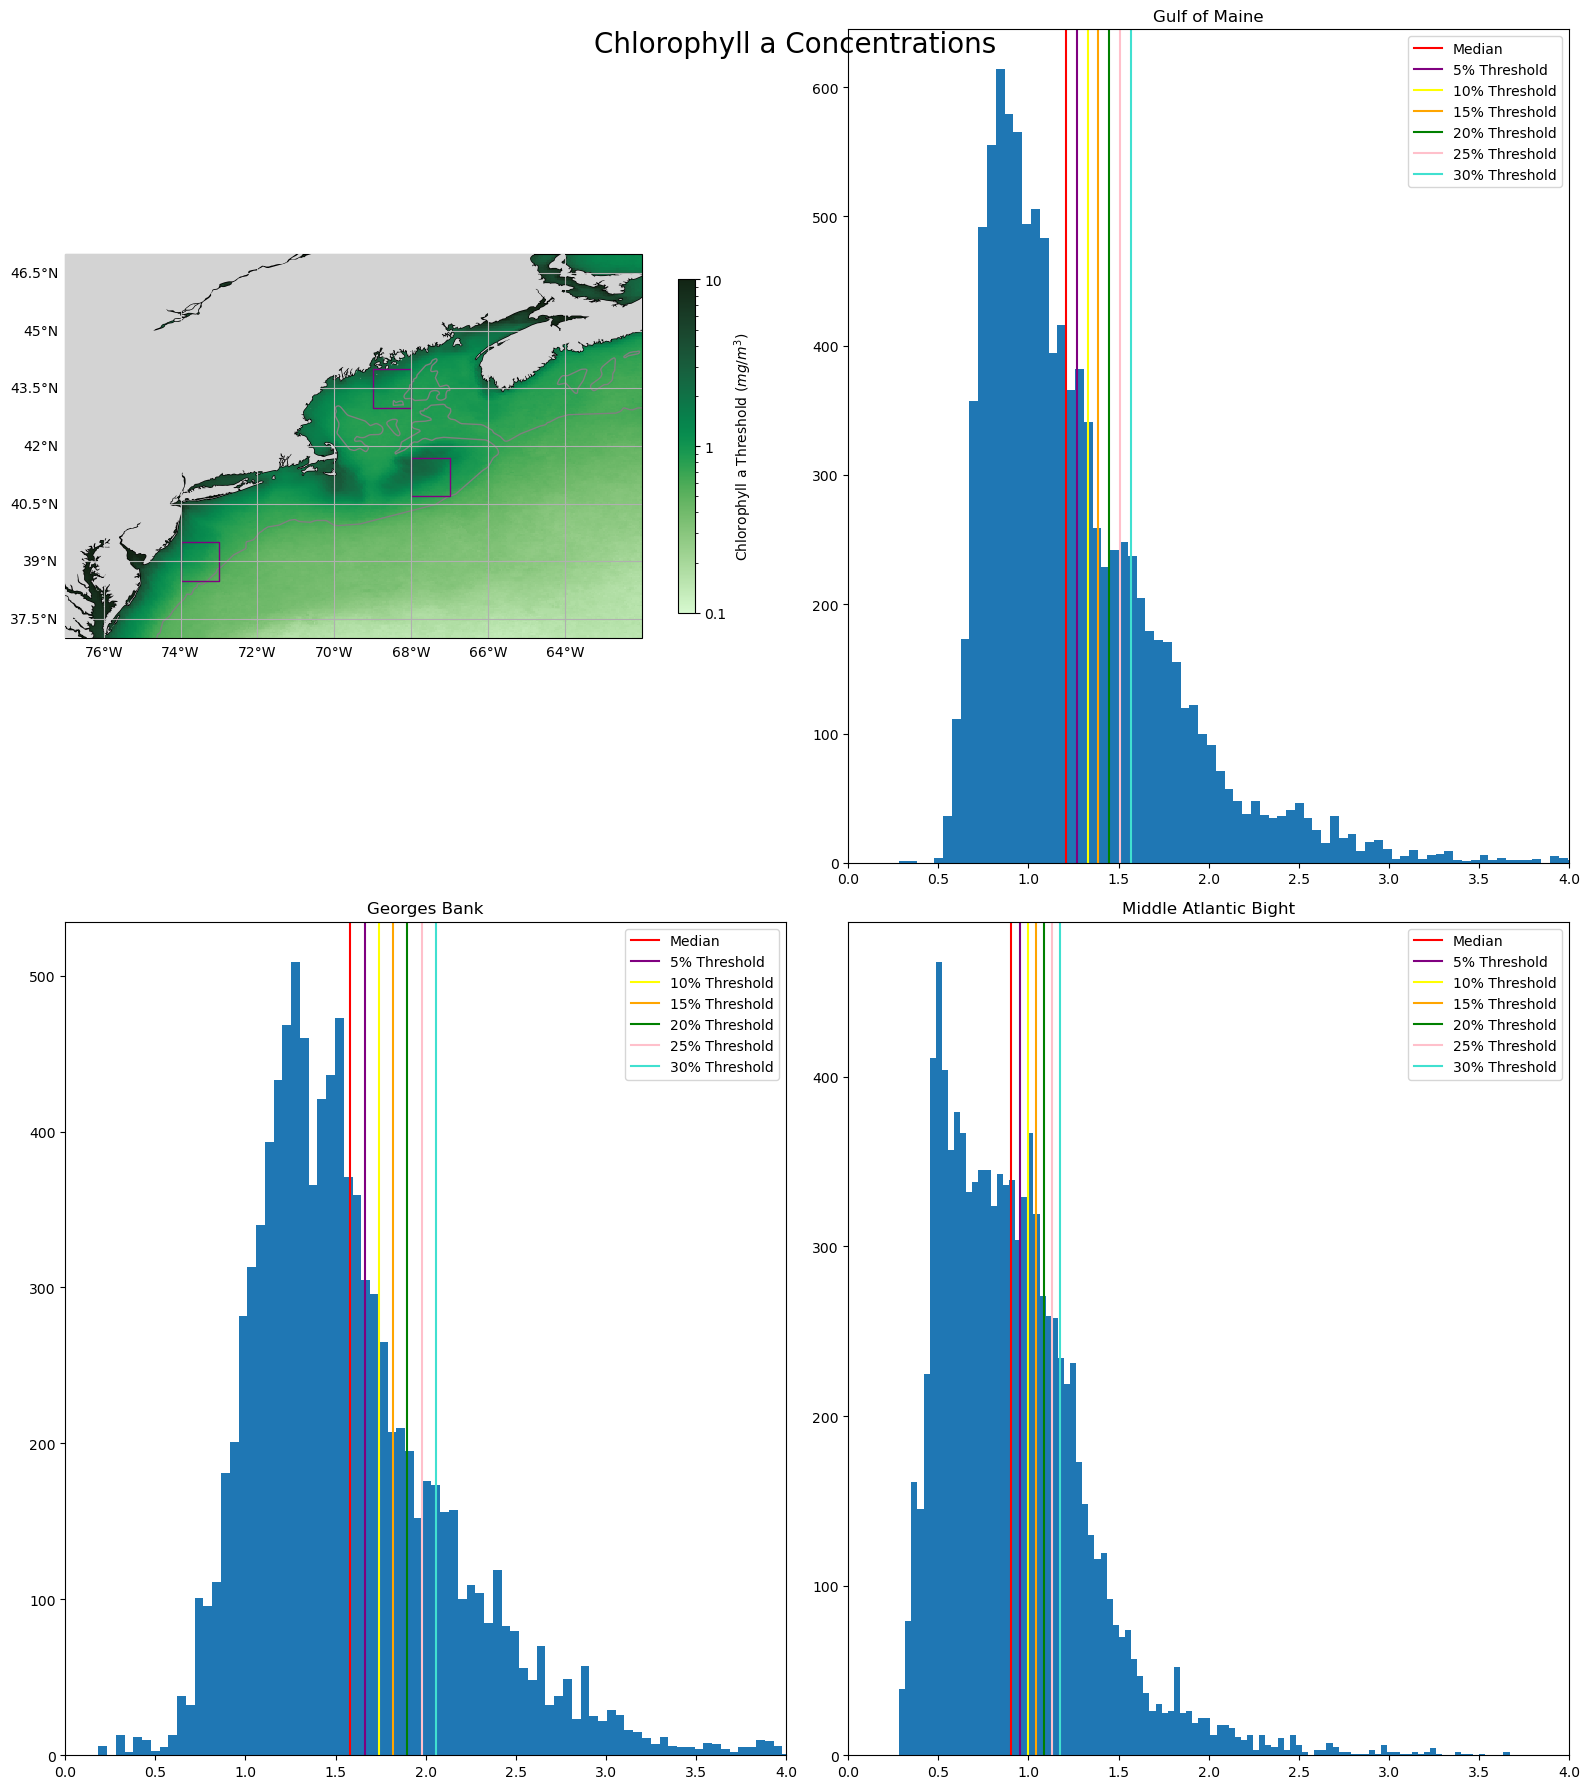

In [65]:
#Set up figure
fig=plt.figure(figsize=(16,18))
ax1 = plt.subplot(2,2,1,projection=crs.PlateCarree())
ax2 = plt.subplot(2,2,2)
ax3 = plt.subplot(2,2,3)
ax4 = plt.subplot(2,2,4)
# Location Map
clim_med = threshold_value(thld=0)
clim_med = clim_med.squeeze()
bathym = cfeature.NaturalEarthFeature(name='bathymetry_K_200', scale='10m', category='physical')
bathym=unary_union(list(bathym.geometries()))
map_projection = cartopy.crs.PlateCarree()
im = ax1.pcolormesh(clim_med.lon,
                    clim_med.lat,
                    clim_med,
                    cmap=cmocean.cm.algae,
                    norm=LogNorm(vmin=0.1, vmax=10.0)
)
custom_ticks = [0.1,1,10]
cb = plt.colorbar(im,ax=ax1,shrink=0.4,label='Chlorophyll a Threshold ($mg/m^3$)',ticks=custom_ticks,format='%g')
ax1.add_feature(cartopy.feature.COASTLINE, linewidth=1)
ax1.add_feature(cartopy.feature.LAND, zorder=100, facecolor='lightgrey')
ax1.add_geometries(bathym, facecolor='none', edgecolor='grey', crs=cartopy.crs.PlateCarree())
ax1.add_geometries(location_GOM, facecolor='none',edgecolor='purple',crs=cartopy.crs.PlateCarree(), label='Gulf of Maine')
ax1.add_geometries(location_GB, facecolor='none',edgecolor='purple',crs=cartopy.crs.PlateCarree(), label='Georges Bank')
ax1.add_geometries(location_MAB, facecolor='none',edgecolor='purple',crs=cartopy.crs.PlateCarree(), label='Middle Atlantic Bight')
ax1.set_extent([-77,-62,37,47])
gl=ax1.gridlines(draw_labels=True)
gl.top_labels = False
gl.right_labels = False
ax.set_title('Chlorophyll a Climatological Median and Histogram Locations', fontsize=14)

#Histograms
local_chl = [ds_GOM,ds_GB,ds_MAB]
clim_med = [clim_GOM,clim_GB,clim_MAB]
clim_5 = [clim_GOM*1.05,clim_GB*1.05,clim_MAB*1.05]
clim_10 = [clim_GOM*1.1,clim_GB*1.1,clim_MAB*1.1]
clim_15 = [clim_GOM*1.15,clim_GB*1.15,clim_MAB*1.15]
clim_20 = [clim_GOM*1.2,clim_GB*1.2,clim_MAB*1.2]
clim_25 = [clim_GOM*1.25,clim_GB*1.25,clim_MAB*1.25]
clim_30 = [clim_GOM*1.3,clim_GB*1.3,clim_MAB*1.3]

hist_axes = [ax2,ax3,ax4]
region_title = ["Gulf of Maine","Georges Bank",'Middle Atlantic Bight']
for i, data in enumerate(local_chl):
    ax = hist_axes[i]
    ax.hist(data,bins=100)
    ax.set_xlim(0,4)
    ax.axvline(clim_med[i][0], color='red',label='Median') #Pulls first value in list and then the 1 value in that value
    ax.axvline(clim_5[i][0], color='purple', label='5% Threshold')
    ax.axvline(clim_10[i][0], color='yellow',label='10% Threshold')
    ax.axvline(clim_15[i][0], color='orange',label='15% Threshold')
    ax.axvline(clim_20[i][0], color='green',label='20% Threshold')
    ax.axvline(clim_25[i][0], color='pink',label='25% Threshold')
    ax.axvline(clim_30[i][0], color='turquoise',label='30% Threshold')
    ax.legend()
    ax.set_title(region_title[i])
plt.tight_layout()
fig.suptitle("Chlorophyll a Concentrations",fontsize=20)

#### Determining the percentage of datapoints that lie above each threshold
Using the variables defined above for plotting, compare each value in the data set to that area's climatological median threshold.
* Threshold options:
    * clim_med = climatological median of the area (must use index of 0-2 in order of GOM, GB, MAB)
    * clim_5 = 5% above the climatological median (Must use indexing for all threshold values)
    * clim_10 = 10% above climatological median
    * clim_15 = 15% above climatological median
    * clim_20 = 20% above climatological median
    * clim_25 = 25% above climatological median
    * clim_30 = 30% above climatological median
* Index options: 0, 1, 2
* Dataset options:
    * ds_GOM = Gulf of Maine subset data
    * ds_GB = Georges Bank subset data
    * ds_MAB = Middle Atlantic Bight subset data


In [ ]:
def percent_above_thld(threshold,index,data):
    threshold=threshold[index].values
    total_above = int((data>threshold).sum().compute())
    percent = (total_above/len(data))*100
    return percent

Testing 5%, 10%, and 15% for each region

In [97]:
GOM_5 = percent_above_thld(clim_5,0,ds_GOM)
print("Gulf of Maine 5%: " + str(GOM_5))
GOM_10 = percent_above_thld(clim_10,0,ds_GOM)
print("Gulf of Maine 10%: " + str(GOM_10))
GOM_15 = percent_above_thld(clim_15,0,ds_GOM)
print("Gulf of Maine 15%: " + str(GOM_15))
GB_5 = percent_above_thld(clim_5,1,ds_GB)
print("Georges Bank 5%: " + str(GB_5))
GB_10 = percent_above_thld(clim_10,1,ds_GB)
print("Georges Bank 10%: " + str(GB_10))
GB_15 = percent_above_thld(clim_15,1,ds_GB)
print("Georges Bank 15%: " + str(GB_15))
MAB_5 = percent_above_thld(clim_5,2,ds_MAB)
print("Middle Atlantic Bight 5%: " + str(MAB_5))
MAB_10 = percent_above_thld(clim_10,2,ds_MAB)
print("Middle Atlantic Bight 10%: " + str(MAB_10))
MAB_15 = percent_above_thld(clim_15,2,ds_MAB)
print("Middle Atlantic Bight 15%: " + str(MAB_15))

Gulf of Maine 5%: 38.589945011783186
Gulf of Maine 10%: 33.994501178318934
Gulf of Maine 15%: 30.65593087195601
Georges Bank 5%: 34.1025137470542
Georges Bank 10%: 29.418695993715634
Georges Bank 15%: 25.60879811468971
Middle Atlantic Bight 5%: 41.182246661429694
Middle Atlantic Bight 10%: 36.7930086410055
Middle Atlantic Bight 15%: 32.24666142969363


#### Shapefile Analysis

Creates the shapefile for each region

In [3]:
shapefile = gpd.read_file('https://github.com/hsynan/READ-EDAB-Synan_hydrographic_climatologies/raw/refs/heads/main/data/shapefiles/NES_5REGIONS.zip')
MAB_south_loc = shapefile.iloc[[0]].set_crs("epsg:4326", inplace=True)
MAB_north_loc = shapefile.iloc[[1]].set_crs("epsg:4326", inplace=True)
GB_whole_loc = shapefile.iloc[[2]].set_crs("epsg:4326", inplace=True)
GOM_west_loc = shapefile.iloc[[3]].set_crs("epsg:4326", inplace=True)
GOM_east_loc = shapefile.iloc[[4]].set_crs("epsg:4326", inplace=True)

Clip the climatology data to the shapefile

In [4]:
clim = xr.open_dataset(r'C:\Users\grace.davis\Documents\GitHub\DATASETS\OCCCI\V6.0\PRODUCTS\NES_4KM_CLIMATOLOGY\CHL\ANNUAL_1998_2020-OCCCI-CHL-NES-STATS.nc')
#clim_med = clim.CHL_median
clim.rio.set_spatial_dims(x_dim="lon", y_dim="lat", inplace=True)
clim.rio.write_crs("epsg:4326", inplace=True)
clim_MAB_s = clim.rio.clip(MAB_south_loc.geometry, shapefile.crs, drop=True)
clim_MAB_s = clim_MAB_s.CHL_median.mean(dim=['lat','lon'])
clipped_clim = clim.rio.clip(MAB_north_loc.geometry, shapefile.crs, drop=True)
clim_MAB_n = clipped_clim.CHL_median.mean(dim=['lat','lon'])
clipped_clim = clim.rio.clip(GB_whole_loc.geometry, shapefile.crs, drop=True)
clim_GB = clipped_clim.CHL_median.mean(dim=['lat','lon'])
clipped_clim = clim.rio.clip(GOM_west_loc.geometry, shapefile.crs, drop=True)
clim_GOM_w = clipped_clim.CHL_median.mean(dim=['lat','lon'])
clipped_clim = clim.rio.clip(GOM_east_loc.geometry, shapefile.crs, drop=True)
clim_GOM_e = clipped_clim.CHL_median.mean(dim=['lat','lon'])

Clip D8 data to the shapefiles

In [5]:
ds = xr.open_mfdataset(r'C:\Users\grace.davis\Documents\GitHub\DATASETS\OCCCI\V6.0\PRODUCTS\NES_4KM_DAY8\CHL\D8_2005*.nc')
ds.rio.set_spatial_dims(x_dim="lon", y_dim="lat", inplace=True)
ds.rio.write_crs("epsg:4326", inplace=True)
clipped_ds = ds.rio.clip(MAB_south_loc.geometry.apply(mapping), shapefile.crs, drop=True)
MAB_south = clipped_ds.CHL_median.mean(dim=['lat','lon'])
clipped_ds = ds.rio.clip(MAB_north_loc.geometry.apply(mapping), shapefile.crs, drop=True)
MAB_north = clipped_ds.CHL_median.mean(dim=['lat','lon'])
clipped_ds = ds.rio.clip(GB_whole_loc.geometry.apply(mapping), shapefile.crs, drop=True)
GB_whole = clipped_ds.CHL_median.mean(dim=['lat','lon'])
clipped_ds = ds.rio.clip(GOM_west_loc.geometry.apply(mapping), shapefile.crs, drop=True)
GOM_west = clipped_ds.CHL_median.mean(dim=['lat','lon'])
clipped_ds = ds.rio.clip(GOM_east_loc.geometry.apply(mapping), shapefile.crs, drop=True)
GOM_east = clipped_ds.CHL_median.mean(dim=['lat','lon'])

Text(0.5, 1.05, 'Chlorophyll a Concentrations')

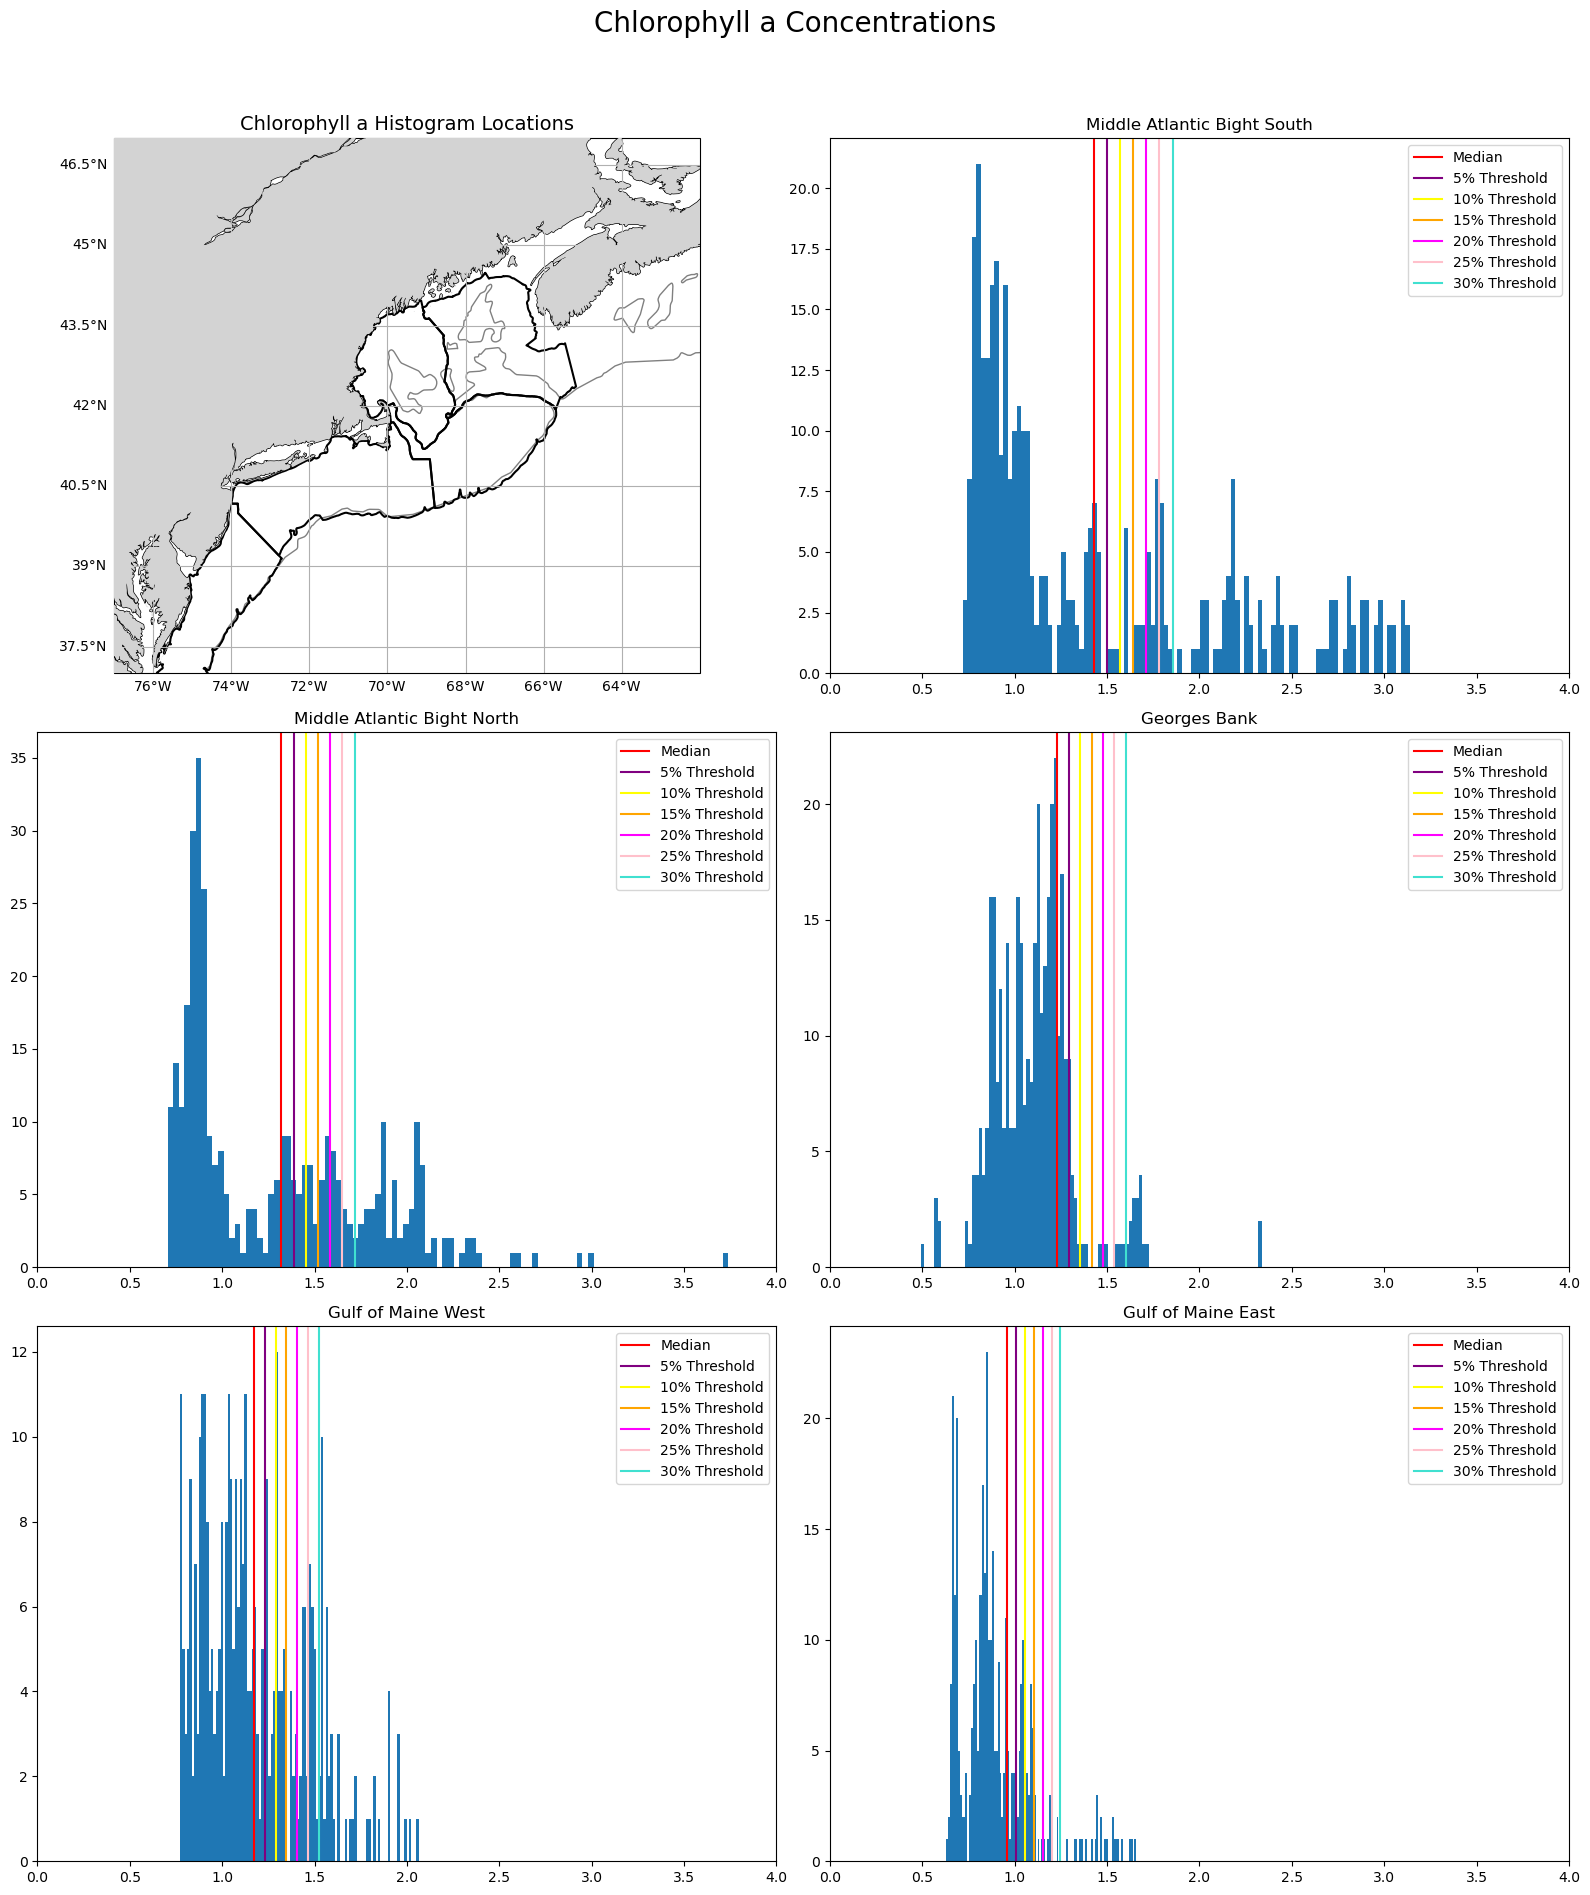

In [19]:
fig=plt.figure(figsize=(16,18))
ax1 = plt.subplot(3,2,1,projection=crs.PlateCarree()) #Locations map
ax2 = plt.subplot(3,2,2) # MAB South
ax3 = plt.subplot(3,2,3) # MAB North
ax4 = plt.subplot(3,2,4) # GB
ax5 = plt.subplot(3,2,5) # GOM West
ax6 = plt.subplot(3,2,6) # GOM East
# Location Map
bathym = cfeature.NaturalEarthFeature(name='bathymetry_K_200', scale='10m', category='physical')
bathym=unary_union(list(bathym.geometries()))
map_projection = cartopy.crs.PlateCarree()
ax1.add_feature(cartopy.feature.COASTLINE, linewidth=1)
ax1.add_feature(cartopy.feature.LAND, zorder=100, facecolor='lightgrey')
ax1.add_geometries(bathym, facecolor='none', edgecolor='grey', crs=cartopy.crs.PlateCarree())
MAB_south_loc.boundary.plot(ax=ax1, color='black', linewidth=1.5)
MAB_north_loc.boundary.plot(ax=ax1, color='black', linewidth=1.5)
GB_whole_loc.boundary.plot(ax=ax1, color='black', linewidth=1.5)
GOM_west_loc.boundary.plot(ax=ax1, color='black', linewidth=1.5)
GOM_east_loc.boundary.plot(ax=ax1, color='black', linewidth=1.5)
ax1.set_extent([-77,-62,37,47])
#ax1.legend()
gl=ax1.gridlines(draw_labels=True)
gl.top_labels = False
gl.right_labels = False
ax1.set_title('Chlorophyll a Histogram Locations', fontsize=14)

#Histograms
local_chl = [MAB_south,MAB_north,GB_whole,GOM_west,GOM_east]
clim_med = [clim_MAB_s,clim_MAB_n,clim_GB,clim_GOM_w,clim_GOM_e]
clim_5 = [clim_MAB_s*1.05,clim_MAB_n*1.05,clim_GB*1.05,clim_GOM_w*1.05,clim_GOM_e*1.05]
clim_10 = [clim_MAB_s*1.10,clim_MAB_n*1.10,clim_GB*1.10,clim_GOM_w*1.10,clim_GOM_e*1.10]
clim_15 = [clim_MAB_s*1.15,clim_MAB_n*1.15,clim_GB*1.15,clim_GOM_w*1.15,clim_GOM_e*1.15]
clim_20 = [clim_MAB_s*1.2,clim_MAB_n*1.2,clim_GB*1.2,clim_GOM_w*1.2,clim_GOM_e*1.2]
clim_25 = [clim_MAB_s*1.25,clim_MAB_n*1.25,clim_GB*1.25,clim_GOM_w*1.25,clim_GOM_e*1.25]
clim_30 = [clim_MAB_s*1.3,clim_MAB_n*1.3,clim_GB*1.3,clim_GOM_w*1.3,clim_GOM_e*1.3]

hist_axes = [ax2,ax3,ax4,ax5,ax6]
region_title = ["Middle Atlantic Bight South","Middle Atlantic Bight North","Georges Bank",'Gulf of Maine West',"Gulf of Maine East"]
for i, dataa in enumerate(local_chl):
    ax = hist_axes[i]
    ax.hist(dataa,bins=100)
    ax.set_xlim(0,4)
    ax.axvline(clim_med[i][0], color='red',label='Median') #Pulls first value in list and then the 1 value in that value
    ax.axvline(clim_5[i][0], color='purple', label='5% Threshold')
    ax.axvline(clim_10[i][0], color='yellow',label='10% Threshold')
    ax.axvline(clim_15[i][0], color='orange',label='15% Threshold')
    ax.axvline(clim_20[i][0], color='magenta',label='20% Threshold')
    ax.axvline(clim_25[i][0], color='pink',label='25% Threshold')
    ax.axvline(clim_30[i][0], color='turquoise',label='30% Threshold')
    ax.legend()
    ax.set_title(region_title[i])
plt.tight_layout()
fig.suptitle("Chlorophyll a Concentrations",fontsize=20,y=1.05)

In [ ]:
#Adding variable to netCDF file
from netCDF4 import Dataset
path = r'C:\Users\grace.davis\Documents\GitHub\DATASETS\OCCCI\V6.0\PRODUCTS\NWA_4KM_DAY8\CHL\D8_19980102_19980109-OCCCI-CHL-NWA-STATS.nc'
ds = xr.open_dataset(path)
cdf = bloom_mask_numeric(path=path) #Creates masked variable
ds['five_percent_thld'] = cdf #Adds variable to ds
ds.to_netcdf(r'C:\Users\grace.davis\Documents\GitHub\DATASETS\OCCCI\V6.0\PRODUCTS\NWA_4KM_DAY8\CHL\D8_19980102_19980109-OCCCI-CHL-NWA-STATS_with_threshold.nc') #Renames the file and saves it with the new variable

### Rate of Change

#### Step 0: Test with climatology data

In [ ]:
def rate_of_change(path=None, lat = 41, lon=-71):
    if path == None:
        files = get_prod_files('CHL',map_region='NES',period='WEEK')
        clim_med = xr.open_mfdataset(files)
    else:
        clim_med = xr.open_dataset(path)
    clim_med = clim_med.CHL_median
    clim_median=clim_med.to_dataframe(name='Chl-a') #Converts it into a pandas dataframe
    clim_roc = clim_median.diff() #Calculate rate of change between each data point
    return clim_roc

roc = rate_of_change()
print(roc)

#def max_roc(days=15,prm=0.2): #Days between peaks and the relative height of each peak value
    #roc = rate_of_change()
    #roc_max = roc.Chl_a.find_peaks(days=days,prominence=prm)
    #return roc_max

#roc_max_values = max_roc
#print(roc_max_values)

#### Step 1: Calculate instantaneous rate of change for each day
1. Make pandas dataframe of chlorophyl data
1. .diff() function
1. Store that in another array

#### Step 2: Set parameters for bloom intiation dates
1. Number of days between start dates
1. Prominence: height of slope peak compared to relative surrounding data
1. Height: Height required (min and/or max) for a peak

#### Step 3: Identify maximum rates of change
Use .find_peaks() function or .find_peaks_cwt() if the data is too noisy

#### Step 4: Extract dates of maximum rates of change

## Part 2: Quantify the Number of Phytoplankton Bloom Days Per Year

#### Actual number of bloom days per year over the time series

Based on the method(s) chosen in Part 1:
1. For each year: 365 - bloom
1. Plot the time series of the data to verify qualitatively

Quantifying bloom days
1. Separate the data out by year
    1. Run the mask for just yearly data?
1. How many daily files meet the bloom criteria?
1. Subtract the bloom daily files from the number of days that year.

Plotting the time series

In [ ]:
path = r'C:\Users\grace.davis\Documents\GitHub\DATASETS\OCCCI\V6.0\PRODUCTS\NES_4KM_DAY8\CHL\D8_1998*.nc'
files = xr.open_mfdataset(path)
#clim_files = xr.open_dataset(r'C:\Users\grace.davis\Documents\GitHub\DATASETS\OCCCI\V6.0\PRODUCTS\NES_4KM_CLIMATOLOGY\CHL\ANNUAL_1998_2020-OCCCI-CHL-NES-STATS.nc')
#print(clim_files)

In [ ]:
med_CHL = files.CHL_median
med_CHL = med_CHL.median(dim=['lat','lon'])
clim_med = clim_files.CHL_median.sel(lat=slice())

In [ ]:
med_CHL = files.CHL_median
med_CHL = med_CHL.median(dim=['lat','lon'])
#clim_med_CHL = clim_files.CHL_median
#clim_med_CHL = clim_med_CHL.groupby('time.dayofyear').first() #Makes days numbered 1-365
#clim_med_CHL = clim_med_CHL.sel(dayofyear=med_CHL.time.dt.dayofyear) #Matches climatology dates (1-365) with the same day of year in the 1998 file
#clim_med_CHL = clim_med_CHL.median(dim=['lat','lon'])
#clim_thld = clim_med_CHL*(1.05)
fig = plt.figure(figsize=(15,8))
plt.plot(med_CHL.time.values,med_CHL,c='purple',label='Median CHL')
#plt.plot(clim_med_CHL.time.values,clim_med_CHL,c='orange',label='Climatological Median')
#plt.plot(clim_thld.time.values,clim_thld,c='teal',label='5% Threshold')
plt.legend()
plt.xticks(rotation=45)
plt.ylabel('Chlorophyll a ($mg/m^3$)')
plt.xlabel('Date')
#upper_error = clim_med_CHL*0.05
#lower_error = np.zeros_like(upper_error) #creates an array of zeroes
#error = [lower_error,upper_error]
#plt.errorbar(clim_med_CHL.time.values,clim_med_CHL,yerr=error,c='orange')
plt.title('1998 Chlorophyll a for NES')

#### Average number of bloom days over the time series

Using the data from above:
1. Calculate the mean (median) number of bloom days for the time series
1. Create an array of the actual days of year
1. Run median (and mean) statistics on the array

## Part 3: Quantify the Number of Phytoplankton Blooms Per Year

#### Actual number of phytoplankton blooms per year over the time series

1. Find the number of peaks (where derivative is 0) above the threshold/place where bloom conditions begin
2. Verify qualitatively with time series

#### Average number of phytoplankton blooms per year over the time series

## Part 4: Bloom Characteristics Analysis

#### Bloom start day

#### Duration of blooms

#### Maximum chlorophyll a

#### Minimum chlorophyll a

#### Mean chlorophyll a

#### Integrated chlorophyll a

#### Location of blooms
1. Find the center of gravity of major blooms

#### Periodicity of Blooms